In [2]:
import ee
ee.Authenticate()


True

In [3]:
ee.Initialize()


In [4]:
import ee
import geemap
import pandas as pd

# Define region of interest (e.g., Punjab, India)
region = ee.Geometry.Rectangle([74, 29, 77, 32])  # min lon, min lat, max lon, max lat

# Time range
start_date = '1986-06-01'
end_date = '2025-10-01'

# Load MOD13Q1 NDVI dataset (16-day composite)
ndvi_dataset = ee.ImageCollection("MODIS/006/MOD13Q1") \
    .filterDate(start_date, end_date) \
    .select('NDVI') \
    .filterBounds(region)

def extract_ndvi(image):
    date = image.date().format('YYYY-MM-dd')
    mean_dict = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=250,
        maxPixels=1e9
    )
    return ee.Feature(None, {
        'date': date,
        'NDVI': mean_dict.get('NDVI')
    })

# Map over images and convert to FeatureCollection
ndvi_fc = ee.FeatureCollection(ndvi_dataset.map(extract_ndvi))

# Export as Pandas DataFrame
ndvi_dict = geemap.ee_to_df(ndvi_fc)
ndvi_dict['NDVI'] = ndvi_dict['NDVI'].astype(float) / 10000  # scale factor
print(ndvi_dict.head())


C:\Users\Rasheek\.conda\envs\tf\lib\site-packages\ee\deprecation.py:207: DeprecationWarning: 

Attention required for MODIS/006/MOD13Q1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/MODIS_006_MOD13Q1

  warnings.warn(warning, category=DeprecationWarning)


       NDVI        date
0  0.633108  2000-02-18
1  0.602434  2000-03-05
2  0.504830  2000-03-21
3  0.324957  2000-04-06
4  0.227094  2000-04-22


In [6]:
ndvi_dict.to_csv('ndvi_dataset.csv')

In [7]:
import requests

def fetch_weather_data(lat=30.9, lon=75.8, start="19860601", end="20241001"):
    url = f"https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "start": start,
        "end": end,
        "latitude": lat,
        "longitude": lon,
        "community": "AG",
        "parameters": "T2M,PRECTOTCORR,RH2M",
        "format": "JSON"
    }
    response = requests.get(url, params=params)
    data = response.json()
    records = data['properties']['parameter']
    dates = list(records['T2M'].keys())
    
    df = pd.DataFrame({
        'date': dates,
        'T2M': [records['T2M'][d] for d in dates],
        'PRECIP': [records['PRECTOTCORR'][d] for d in dates],
        'RH2M': [records['RH2M'][d] for d in dates],
    })
    df['date'] = pd.to_datetime(df['date'])
    return df

weather_df = fetch_weather_data()
print(weather_df.head())


        date    T2M  PRECIP   RH2M
0 1986-06-01  31.13    1.25  25.48
1 1986-06-02  31.35    3.38  30.59
2 1986-06-03  33.00    0.00  25.53
3 1986-06-04  32.54    1.91  23.78
4 1986-06-05  33.34    0.00  21.83


In [9]:
weather_df.to_csv('weather_datset.csv')

In [10]:
ndvi_dict['date'] = pd.to_datetime(ndvi_dict['date'])
merged_df = pd.merge(weather_df, ndvi_dict, on='date', how='inner')
print(merged_df.head())


        date    T2M  PRECIP   RH2M      NDVI
0 2000-02-18  13.48    0.00  34.73  0.633108
1 2000-03-05  16.53    0.00  32.87  0.602434
2 2000-03-21  21.35    0.09  27.08  0.504830
3 2000-04-06  25.66    0.00   7.20  0.324957
4 2000-04-22  33.84    0.00  16.48  0.227094


In [11]:
len(merged_df)

529

In [12]:
data = merged_df

In [13]:
yield_df = pd.read_csv(r'./Table_4.7_Yield_Wheat.csv')

In [21]:
yield_df

,District/Year,2022,2021,2020,2019,2018,2017,2016,2015,2014,...,1977,1976,1975,1974,1973,1972,1971,1970,1969,1968
0,Gurdaspur,4220,4524,4175,4717,4733,4606,4654,3356,4469,...,2106.0,2095.0,2188.0,1868.0,2015.0,2077.0,2089.0,1955.0,1953.0,1315.0
1,Pathankot,3650,4344,3944,3984,4018,4066,4049,2727,3979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Amritsar,4451,4763,4533,4813,4866,4948,4478,3914,4869,...,2493.0,2424.0,2276.0,2051.0,2198.0,2749.0,2326.0,2680.0,2342.0,1570.0
3,Tarn Taran,4287,4704,4546,4898,4685,4791,4524,4132,5088,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kapurthala,3994,4616,4655,4733,4842,4922,4259,3996,4935,...,2129.0,2148.0,2140.0,1920.0,2127.0,1916.0,2527.0,2065.0,2302.0,1597.0
5,Jalandhar,4223,4900,5026,4968,5063,4847,4456,4102,4950,...,2420.0,2453.0,2507.0,2349.0,2504.0,2296.0,2492.0,2346.0,2311.0,1741.0
6,SBS Nagar,3862,4935,5078,5005,5003,4925,4720,3712,4939,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Hoshiarpur,3621,4145,4287,5244,4337,4124,4078,3623,4335,...,1840.0,2120.0,2070.0,1687.0,1885.0,1435.0,1468.0,1283.0,1521.0,1269.0
8,Rupnagar,3610,4513,4326,4561,4873,4827,4286,4032,4578,...,1940.0,2045.0,1803.0,1864.0,1538.0,1949.0,1948.0,1925.0,1789.0,1676.0
9,SAS Nagar,2704,4368,4521,4633,4968,4707,4647,3959,4473,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Melt the wide dataframe to long format
yield_long = yield_df.melt(id_vars=["District/Year"], var_name="year", value_name="yield_kg_per_ha")

# Clean column names
yield_long = yield_long.rename(columns={"District/Year": "district"})
yield_long['year'] = yield_long['year'].astype(str)

# Drop rows with missing yield
yield_long = yield_long.dropna(subset=['yield_kg_per_ha'])

# Convert year to int
yield_long['year'] = yield_long['year'].astype(int)

yield_long


,district,year,yield_kg_per_ha
0,Gurdaspur,2022,4220.0
1,Pathankot,2022,3650.0
2,Amritsar,2022,4451.0
3,Tarn Taran,2022,4287.0
4,Kapurthala,2022,3994.0
...,...,...,...
1253,Ferozepur,1968,1998.0
1258,Bathinda,1968,1939.0
1260,Sangrur,1968,1628.0
1262,Patiala,1968,1839.0


In [18]:
districts = yield_long["district"].unique()
years = merged_df["year"].unique()

# Create cartesian product of districts and years
import itertools
district_year_pairs = list(itertools.product(districts, years))

# Create DataFrame
district_weather_df = pd.DataFrame(district_year_pairs, columns=["district", "year"])
district_weather_df = district_weather_df.merge(merged_df, on="year", how="left")


<bound method DataFrame.value_counts of         district  year       date    T2M  PRECIP   RH2M      NDVI
0      Gurdaspur  2000 2000-02-18  13.48    0.00  34.73  0.633108
1      Gurdaspur  2000 2000-03-05  16.53    0.00  32.87  0.602434
2      Gurdaspur  2000 2000-03-21  21.35    0.09  27.08  0.504830
3      Gurdaspur  2000 2000-04-06  25.66    0.00   7.20  0.324957
4      Gurdaspur  2000 2000-04-22  33.84    0.00  16.48  0.227094
...          ...   ...        ...    ...     ...    ...       ...
12162      Total  2022 2022-12-03  16.86    0.00  50.56  0.484285
12163      Total  2022 2022-12-19  14.80    0.00  48.57  0.545029
12164      Total  2023 2023-01-01  12.03    0.00  55.25  0.646440
12165      Total  2023 2023-01-17   8.71    0.00  40.87  0.677388
12166      Total  2023 2023-02-02  13.49    0.00  56.12  0.685029

[12167 rows x 7 columns]>

In [22]:
# Extract year


merged_df["year"] = merged_df["date"].dt.year

# Aggregate the features by year (seasonal features like T2M mean, PRECIP sum, etc.)
seasonal_features = merged_df.groupby("year").agg({
    "T2M": "mean",
    "PRECIP": "sum",
    "RH2M": "mean",
    "NDVI": "mean"
}).reset_index()

# Merge with yield data (assuming average yield across Punjab for now)
average_yield_per_year = yield_long.groupby("year")["yield_kg_per_ha"].mean().reset_index()

# Merge features with yield
final_df = pd.merge(seasonal_features, average_yield_per_year, on="year", how="inner")

final_df

,year,T2M,PRECIP,RH2M,NDVI,yield_kg_per_ha
0,2000,27.188000,18.54,32.246000,0.397421,4653.222222
1,2001,26.163913,35.90,36.241739,0.425319,4506.166667
2,2002,27.210870,48.47,33.830870,0.409185,4491.333333
3,2003,24.885217,59.69,44.667826,0.416778,4134.000000
4,2004,26.177391,45.21,38.476957,0.437946,4168.277778
5,2005,24.574348,37.66,43.636957,0.446766,4180.388889
6,2006,26.086522,42.82,44.433478,0.449728,4144.900000
7,2007,25.886522,17.09,40.222609,0.462683,4193.380952
8,2008,24.504348,104.32,50.545652,0.449401,4477.285714
9,2009,26.185652,17.26,36.646087,0.437336,4381.952381


In [28]:
final_df.to_csv('./final.csv')

In [1]:
import pandas as pd 
final_df = pd.read_csv('./final.csv')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import numpy as np

data = final_df.drop(columns=['Unnamed: 0', 'year'])

# Normalize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

pca = PCA(n_components=0.95)
reduced_data = pca.fit_transform(scaled_data)

nn = NearestNeighbors(n_neighbors=3)
nn.fit(reduced_data)

num_samples = 1000
synthetic_data = []
for _ in range(num_samples):
    idx = np.random.randint(0, reduced_data.shape[0])
    neighbors = nn.kneighbors([reduced_data[idx]], return_distance=False)
    neighbor = reduced_data[neighbors[0][np.random.randint(1, len(neighbors[0]))]]
    alpha = np.random.rand()
    interpolated = reduced_data[idx] * alpha + neighbor * (1 - alpha)
    synthetic_data.append(interpolated)

synthetic_data = pca.inverse_transform(synthetic_data)
synthetic_data = scaler.inverse_transform(synthetic_data)

synthetic_df = pd.DataFrame(synthetic_data, columns=data.columns)
synthetic_df.head()


In [ ]:
# Save the synthetic dataset to a CSV file
synthetic_file_path = './synthetic_dataset.csv'
synthetic_df.to_csv(synthetic_file_path, index=False)

synthetic_file_path


In [11]:
final_df = pd.read_csv('C:\mini project\synthetic_dataset.csv')

In [12]:
final_df

,T2M,PRECIP,RH2M,NDVI,yield_kg_per_ha
0,26.205055,33.670219,36.847430,0.424711,4500.198036
1,25.315040,52.105083,44.076238,0.478201,4971.535787
2,24.236113,67.219390,51.708162,0.518204,5052.257354
3,25.405564,51.721753,42.747849,0.440251,4118.767251
4,24.649827,44.231739,46.539673,0.486693,5025.559281
...,...,...,...,...,...
995,25.303454,45.351177,43.133343,0.471762,4997.559496
996,25.296871,41.513166,42.597528,0.468104,5012.347868
997,26.202993,36.422825,36.995182,0.424699,4481.687881
998,26.873329,44.928477,34.193368,0.415165,4491.561531


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("synthetic_dataset.csv")

train_val, test = train_test_split(df, test_size=0.2, random_state=42)

train, val = train_test_split(train_val, test_size=0.25, random_state=42)

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

train.to_csv("train.csv", index=False)
val.to_csv("validation.csv", index=False)
test.to_csv("test.csv", index=False)


Train shape: (600, 5)
Validation shape: (200, 5)
Test shape: (200, 5)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, r2_score

df = train
val_df = val

X = df[['T2M', 'PRECIP', 'RH2M', 'NDVI']]
y = df['yield_kg_per_ha']
X_val = val_df[['T2M', 'PRECIP', 'RH2M', 'NDVI']]
y_val = val_df['yield_kg_per_ha']

# Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_val_scaled = scaler.transform(X_val)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,
    validation_data=(X_val_scaled, y_val),
    callbacks=callbacks,
    verbose=1
)




Epoch 1/200
60/60 [==============================] - 0s 3ms/step - loss: 20794714.0000 - val_loss: 20839834.0000
Epoch 2/200
60/60 [==============================] - 0s 2ms/step - loss: 19875156.0000 - val_loss: 18316980.0000
Epoch 3/200
60/60 [==============================] - 0s 2ms/step - loss: 13973276.0000 - val_loss: 8411680.0000
Epoch 4/200
60/60 [==============================] - 0s 2ms/step - loss: 4627230.5000 - val_loss: 2792525.7500
Epoch 5/200
60/60 [==============================] - 0s 2ms/step - loss: 2517913.5000 - val_loss: 2169034.7500
Epoch 6/200
60/60 [==============================] - 0s 2ms/step - loss: 1858090.0000 - val_loss: 1617671.2500
Epoch 7/200
60/60 [==============================] - 0s 2ms/step - loss: 1318918.8750 - val_loss: 1156024.7500
Epoch 8/200
60/60 [==============================] - 0s 2ms/step - loss: 931933.6250 - val_loss: 839663.9375
Epoch 9/200
60/60 [==============================] - 0s 2ms/step - loss: 652238.1250 - val_loss: 596887.0625


4/4 [==============================] - 0s 1ms/step
Mean Absolute Error (MAE): 0.37
R² Score: 1.0000


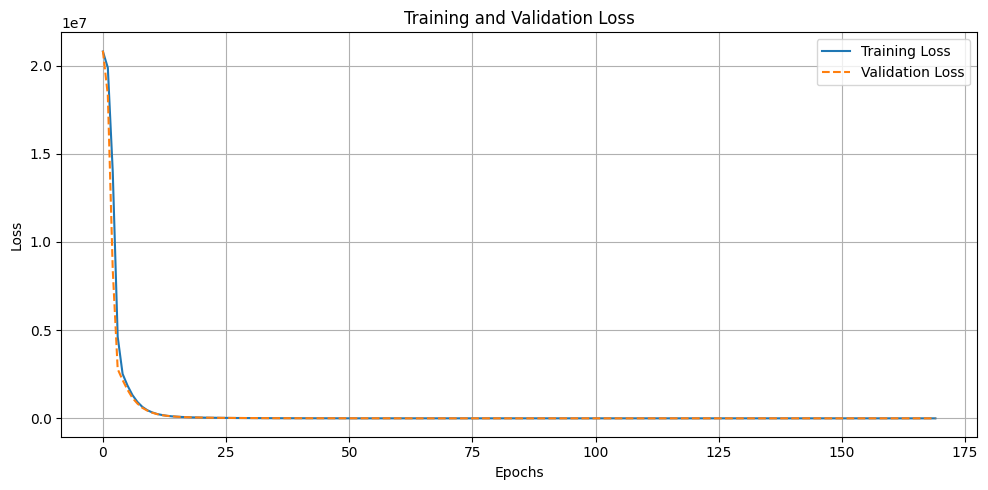

In [ ]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R² Score: {r2:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)


mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Random Forest MAE: {mae_rf}')
print(f'Random Forest R²: {r2_rf}')


Random Forest MAE: 15.34079238796318
Random Forest R²: 0.9880420241001264


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np

data = final_df

features = ['NDVI', 'T2M', 'PRECIP', 'RH2M']
X = data[features]
y = data['yield_kg_per_ha']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


RMSE: 53.20
R² Score: 0.97


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score


gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42)


gbr_model.fit(X_train, y_train)


y_pred_gbr = gbr_model.predict(X_test)


mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f'Gradient Boosting MAE: {mae_gbr}')
print(f'Gradient Boosting R²: {r2_gbr}')


Gradient Boosting MAE: 50.28498722775812
Gradient Boosting R²: 0.9361505342547312


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score


svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)


svr_model.fit(X_train, y_train)


y_pred_svr = svr_model.predict(X_test)


mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f'Support Vector Regression MAE: {mae_svr}')
print(f'Support Vector Regression R²: {r2_svr}')


Support Vector Regression MAE: 188.68924855495135
Support Vector Regression R²: 0.2709611454324824
